# Day 6 lab: pruning, distillation, and model selection

**Goal.** You prune a CNN, you distill a teacher into a small student, you
quantize the best models, and you select one model for each board of the
course from a trade-off plot.

**Deliverable.** The plot `tradeoff.png` with at least six models, and the
file `report.md` with your selection and the Decision Log.

**Time.** Part A: 45 min, sections 0 to 4. Part B: 45 min, sections 5 to 7.
Part C: 40 min, sections 8 to 10.

**How to work.** Run the cells in order. A cell with the mark
`TODO (student)` has a task. The notebook has seven tasks. The cell after a
task checks your result. An experiment starts only when its task is complete.

## 0. Setup

Run this cell first. It loads the dataset Fashion-MNIST and the two trained
models of the folder `models/`. The first run downloads the dataset: about
30 MB.

- `baseline.keras`: the CNN of the lecture with 16, 32, and 64 filters.
- `teacher.keras`: the same network with 32, 64, and 128 filters.

The two models are trained. A training from the start needs too much time
for a lab.

In [1]:
import contextlib
import gzip
import io
import os
import platform
import sys
import time
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"     # no start messages of TensorFlow

import keras
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from ai_edge_litert.interpreter import Interpreter
from keras import ops

tf.get_logger().setLevel("ERROR")            # no INFO lines of the converter
warnings.filterwarnings("ignore", message="Statistics for quantized inputs")

print("python    ", sys.version.split()[0])
print("numpy     ", np.__version__)
print("tensorflow", tf.__version__)
print("keras     ", keras.__version__)
print("machine   ", platform.machine())

# The lab folder. The notebook of the folder solutions/ uses the folder above.
LAB = "." if os.path.isdir("models") else ".."
CLASS_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal",
               "Shirt", "Sneaker", "Bag", "Ankle boot"]
CONVS = ("conv_1", "conv_2", "conv_3")
PRUNABLE = CONVS + ("output",)

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = (x_train / 255.0).astype("float32")[..., None]
x_test = (x_test / 255.0).astype("float32")[..., None]
print()
print(f"training set: {x_train.shape[0]} images of "
      f"{x_train.shape[1]} x {x_train.shape[2]}, test set: {x_test.shape[0]} images")


@contextlib.contextmanager
def no_status_messages():
    '''Hide the status lines that TensorFlow prints during a conversion.'''
    sys.stdout.flush()
    sys.stderr.flush()
    saved = os.dup(1), os.dup(2)
    with open(os.devnull, "w") as null, contextlib.redirect_stdout(io.StringIO()):
        os.dup2(null.fileno(), 1)
        os.dup2(null.fileno(), 2)
        try:
            yield
        finally:
            os.dup2(saved[0], 1)
            os.dup2(saved[1], 2)
            os.close(saved[0])
            os.close(saved[1])


def build_cnn(widths=(16, 32, 64), logits=False, name="cnn"):
    '''Return the CNN of the lecture with the given numbers of filters.'''
    return keras.Sequential([
        keras.Input((28, 28, 1), name="image"),
        keras.layers.Conv2D(widths[0], 3, padding="same", activation="relu",
                            name="conv_1"),
        keras.layers.MaxPooling2D(name="pool_1"),
        keras.layers.Conv2D(widths[1], 3, padding="same", activation="relu",
                            name="conv_2"),
        keras.layers.MaxPooling2D(name="pool_2"),
        keras.layers.Conv2D(widths[2], 3, padding="same", activation="relu",
                            name="conv_3"),
        keras.layers.GlobalAveragePooling2D(name="pool_3"),
        keras.layers.Dense(10, activation=None if logits else "softmax",
                           name="output"),
    ], name=name)


def compile_model(model, learning_rate=0.001):
    '''Set the optimizer, the loss, and the metric of a model.'''
    model.compile(optimizer=keras.optimizers.Adam(learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])


def keras_accuracy(model):
    '''Return the test accuracy of a Keras model in percent.'''
    outputs = model.predict(x_test, verbose=0, batch_size=1000)
    return 100 * float((outputs.argmax(axis=1) == y_test).mean())


def widths_of(model):
    '''Return the numbers of filters of the three convolutions.'''
    return [model.get_layer(name).filters for name in CONVS]


def copy_of(model):
    '''Return a copy of a CNN that is ready for fine-tuning.'''
    copy = build_cnn(widths_of(model))
    copy.set_weights(model.get_weights())
    compile_model(copy, 0.0005)
    return copy


baseline = keras.models.load_model(os.path.join(LAB, "models", "baseline.keras"))
teacher = keras.models.load_model(os.path.join(LAB, "models", "teacher.keras"))
compile_model(baseline)
print(f"baseline: {baseline.count_params()} parameters, "
      f"test accuracy {keras_accuracy(baseline):.1f} percent")
print(f"teacher:  {teacher.count_params()} parameters, "
      f"test accuracy {keras_accuracy(teacher):.1f} percent")

python     3.10.12
numpy      2.2.6
tensorflow 2.21.0
keras      3.12.4
machine    x86_64



training set: 60000 images of 28 x 28, test set: 10000 images


baseline: 23946 parameters, test accuracy 89.1 percent


teacher:  93962 parameters, test accuracy 90.3 percent


The next cell has the measurement functions of this lab. They give the four
numbers that a device sees: the file size, the accuracy of the LiteRT file,
the latency, and the peak of the activations. You do not change this code.

The latency is the time of one inference on your laptop with one thread. It
is not the latency of a board. Day 9 measures on the boards.

In [2]:
def to_litert(model):
    '''Return the float32 LiteRT file of a Keras model.'''
    with no_status_messages():
        return tf.lite.TFLiteConverter.from_keras_model(model).convert()


def to_int8(model):
    '''Return the int8 LiteRT file: full integer quantization (Day 4).'''
    generator = np.random.default_rng(0)
    picked = np.concatenate([generator.permutation(np.flatnonzero(y_train == k))[:20]
                             for k in range(10)])
    calibration = x_train[generator.permutation(picked)]

    def representative_dataset():
        for i in range(len(calibration)):
            yield [calibration[i:i + 1]]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    with no_status_messages():
        return converter.convert()


def make_interpreter(tflite_model):
    '''Return a LiteRT interpreter with one thread.'''
    with no_status_messages():
        interpreter = Interpreter(model_content=tflite_model, num_threads=1)
        interpreter.allocate_tensors()
    return interpreter


def prepared_inputs(interpreter, x):
    '''Return x in the type of the input tensor of the model.'''
    details = interpreter.get_input_details()[0]
    if details["dtype"] == np.int8:
        S, Z = details["quantization"]
        return np.clip(np.round(x / S) + Z, -128, 127).astype(np.int8)
    return x


def litert_accuracy(tflite_model):
    '''Return the test accuracy of a LiteRT file in percent.'''
    interpreter = make_interpreter(tflite_model)
    inp = interpreter.get_input_details()[0]["index"]
    out = interpreter.get_output_details()[0]["index"]
    x = prepared_inputs(interpreter, x_test)
    correct = 0
    for k in range(len(x)):
        interpreter.set_tensor(inp, x[k:k + 1])
        interpreter.invoke()
        correct += int(interpreter.get_tensor(out)[0].argmax() == y_test[k])
    return 100 * correct / len(x)


def latency_us(tflite_model, runs=3, count=300):
    '''Return the median time of one inference in microseconds.'''
    interpreter = make_interpreter(tflite_model)
    inp = interpreter.get_input_details()[0]["index"]
    x = prepared_inputs(interpreter, x_test[:count])
    medians = []
    for _ in range(runs):
        times = []
        for k in range(count):
            interpreter.set_tensor(inp, x[k:k + 1])
            start = time.perf_counter()
            interpreter.invoke()
            times.append(time.perf_counter() - start)
        medians.append(np.median(times[20:]))
    return 1e6 * float(np.median(medians))


def peak_bytes(tflite_model):
    '''Return the peak of the activations: the largest sum of the input and
    the output of one operator, in bytes.'''
    interpreter = make_interpreter(tflite_model)
    details = {d["index"]: d for d in interpreter.get_tensor_details()}

    def size(index):
        return (int(np.prod(details[index]["shape"]))
                * np.dtype(details[index]["dtype"]).itemsize)

    peak = 0
    for op in interpreter._get_ops_details():
        if op["op_name"] == "DELEGATE":
            continue
        peak = max(peak, size(op["inputs"][0]) + size(op["outputs"][0]))
    return peak


baseline_file = to_litert(baseline)
print(f"baseline, float32 LiteRT file: {len(baseline_file)} bytes")
print(f"  accuracy {litert_accuracy(baseline_file):.1f} percent, "
      f"latency {latency_us(baseline_file):.0f} microseconds, "
      f"peak of the activations {peak_bytes(baseline_file)} bytes")

baseline, float32 LiteRT file: 99320 bytes


  accuracy 89.1 percent, latency 73 microseconds, peak of the activations 62720 bytes


# Part A: pruning (45 min)

## 1. The magnitude mask (10 min)

Magnitude pruning removes the weights with the smallest absolute values. A
mask has the value 1 for a weight that stays and the value 0 for a weight
that goes:

$$\hat{W} = M \odot W \qquad M_{ij} = 1 \ \text{if} \ |W_{ij}| > \delta, \ \text{and} \ 0 \ \text{in all other cases}$$

The threshold $\delta$ comes from the sparsity: for a sparsity of 0.8, it is
the value that 80 percent of the magnitudes are below.

**Task 1.** Complete the function `magnitude_mask`. Use `np.abs` and
`np.quantile`.

In [3]:
def magnitude_mask(weights, sparsity):
    '''Return (mask, threshold) for an array of weights.

    The mask has the shape of the weights and the type float32: 1.0 for a
    weight with a magnitude above the threshold, and 0.0 for all others.
    '''
    threshold = float(np.quantile(np.abs(weights), sparsity))
    mask = (np.abs(weights) > threshold).astype("float32")
    return mask, threshold

In [4]:
def check_task_1():
    '''Compare magnitude_mask with a known case.'''
    weights = np.array([[0.5, -0.1, 0.05, -0.9, 0.3],
                        [-0.02, 0.7, -0.4, 0.2, -0.6]], dtype="float32")
    mask, threshold = magnitude_mask(weights, 0.6)
    expected = np.array([[1, 0, 0, 1, 0], [0, 1, 0, 0, 1]], dtype="float32")
    correct = (np.array_equal(mask, expected) and 0.4 <= threshold < 0.5
               and mask.dtype == np.float32)
    print("Task 1:", "complete" if correct else "not complete")
    return correct


task_1_complete = check_task_1()

all_weights = np.concatenate([baseline.get_layer(name).kernel.numpy().ravel()
                              for name in PRUNABLE])
print()
print(f"the baseline has {all_weights.size} weights in its kernels")
for sparsity in (0.5, 0.8):
    mask, threshold = magnitude_mask(all_weights, sparsity)
    print(f"sparsity {sparsity}: threshold {threshold:.3f}, "
          f"{int(mask.sum())} weights stay")

Task 1: complete

the baseline has 23824 weights in its kernels
sparsity 0.5: threshold 0.135, 11912 weights stay
sparsity 0.8: threshold 0.301, 4764 weights stay


## 2. Unstructured pruning (15 min)

The experiment prunes the baseline with one threshold for all layers (a
global threshold). For each sparsity it measures:

- the accuracy before the fine-tuning and after 2 epochs of fine-tuning,
- the size of the LiteRT file, and its size after the compression tool
  `gzip`,
- the latency on your laptop.

During the fine-tuning, the mask stays: a weight that is 0 stays 0.

**Task 2.** Write your prediction **before** you run the experiment. The
prediction is part of the assessment. A wrong prediction costs no points. A
missing prediction does.

In [5]:
# Example of a prediction. Your prediction can be different.
prediction_unstructured = {
    # a number in percent
    "accuracy at a sparsity of 80 percent, before fine-tuning": "40",
    "accuracy at a sparsity of 80 percent, after fine-tuning": "86",
    # "smaller", "equal", or "larger", against the dense model
    "LiteRT file at a sparsity of 80 percent": "equal",
    "latency at a sparsity of 80 percent": "equal",
}
for question, answer in prediction_unstructured.items():
    print(f"{question:<58} {answer}")

accuracy at a sparsity of 80 percent, before fine-tuning   40
accuracy at a sparsity of 80 percent, after fine-tuning    86
LiteRT file at a sparsity of 80 percent                    equal
latency at a sparsity of 80 percent                        equal


In [6]:
class KeepMasks(keras.callbacks.Callback):
    '''Set the pruned weights back to 0 after each training step.'''

    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        apply_masks(self.model, self.masks)


def global_masks(model, sparsity):
    '''Return one mask for each layer, from one threshold for all layers.'''
    values = np.concatenate([model.get_layer(name).kernel.numpy().ravel()
                             for name in PRUNABLE])
    _, threshold = magnitude_mask(values, sparsity)
    return {name: (np.abs(model.get_layer(name).kernel.numpy())
                   > threshold).astype("float32") for name in PRUNABLE}


def apply_masks(model, masks):
    '''Multiply each kernel with its mask.'''
    for name, mask in masks.items():
        layer = model.get_layer(name)
        layer.kernel.assign(layer.kernel.numpy() * mask)


candidates = {"baseline 16-32-64": baseline}     # the models for Part C

if task_1_complete:
    print(f"{'sparsity':>9}{'weights not 0':>15}{'before':>9}{'after':>8}"
          f"{'file':>9}{'gzip':>8}{'latency':>9}")
    dense_file = to_litert(baseline)
    print(f"{'none':>9}{all_weights.size:>15}{'':>9}{keras_accuracy(baseline):>8.1f}"
          f"{len(dense_file):>9}{len(gzip.compress(dense_file)):>8}"
          f"{latency_us(dense_file):>9.0f}")
    for sparsity in (0.5, 0.7, 0.8, 0.9):
        model = copy_of(baseline)
        masks = global_masks(model, sparsity)
        apply_masks(model, masks)
        before = keras_accuracy(model)
        keras.utils.set_random_seed(0)
        model.fit(x_train, y_train, epochs=2, batch_size=128, verbose=0,
                  callbacks=[KeepMasks(masks)])
        not_zero = sum(int(np.count_nonzero(model.get_layer(name).kernel.numpy()))
                       for name in PRUNABLE)
        file = to_litert(model)
        print(f"{sparsity:>9.2f}{not_zero:>15}{before:>9.1f}{keras_accuracy(model):>8.1f}"
              f"{len(file):>9}{len(gzip.compress(file)):>8}{latency_us(file):>9.0f}")
        if sparsity == 0.8:
            candidates["unstructured 80 percent"] = model
    print()
    print("Accuracy in percent, file sizes in bytes, latency in microseconds.")
else:
    print("Task 1 is not complete. The experiment does not run.")

 sparsity  weights not 0   before   after     file    gzip  latency


     none          23824             89.1    99320   90877       73


     0.50          11912     79.9    90.0    99320   54423       66


     0.70           7147     50.9    88.8    99320   36775       66


     0.80           4764     23.4    85.7    99320   27498       66


     0.90           2383     10.0    76.4    99320   17796       66

Accuracy in percent, file sizes in bytes, latency in microseconds.


## 3. Structured pruning (15 min)

Structured pruning removes complete filters. The result is a smaller dense
model. The score of a filter is the sum of the absolute values of its
weights. The filters with the smallest scores go.

A kernel of a convolution has the shape `(height, width, input channels,
filters)`. The last axis is the filter.

**Task 3.** Complete the function `filter_scores`. It returns one score for
each filter.

In [7]:
def filter_scores(kernel):
    '''Return the sum of the absolute weights of each filter.

    kernel: array with the shape (height, width, input channels, filters).
    The result has one value for each filter.
    '''
    return np.abs(kernel).sum(axis=(0, 1, 2))

In [8]:
def check_task_3():
    '''Compare filter_scores with a known case.'''
    kernel = np.zeros((3, 3, 2, 4), dtype="float32")
    kernel[..., 0] = 0.5
    kernel[..., 1] = -0.1
    kernel[0, 0, 0, 2] = 2.0
    scores = np.asarray(filter_scores(kernel), dtype="float64")
    correct = scores.shape == (4,) and np.allclose(scores, [9.0, 1.8, 2.0, 0.0])
    print("Task 3:", "complete" if correct else "not complete")
    return correct


def prune_filters(model, keep):
    '''Return a smaller model with the best filters. keep: part from 0 to 1.'''
    kept = []
    for name in CONVS:
        scores = filter_scores(model.get_layer(name).kernel.numpy())
        number = max(2, int(round(len(scores) * keep)))
        kept.append(np.sort(np.argsort(scores)[-number:]))
    small = build_cnn([len(k) for k in kept])
    previous = None
    for name, index in zip(CONVS, kept):
        kernel, bias = model.get_layer(name).get_weights()
        if previous is not None:
            kernel = kernel[:, :, previous, :]     # the channels that still exist
        small.get_layer(name).set_weights([kernel[:, :, :, index], bias[index]])
        previous = index
    kernel, bias = model.get_layer("output").get_weights()
    small.get_layer("output").set_weights([kernel[previous, :], bias])
    compile_model(small, 0.0005)
    return small


task_3_complete = check_task_3()
print()
if task_3_complete:
    print(f"{'filters':>12}{'parameters':>12}{'before':>9}{'after':>8}{'file':>9}"
          f"{'latency':>9}{'peak':>8}")
    file = to_litert(baseline)
    print(f"{'16-32-64':>12}{baseline.count_params():>12}{'':>9}"
          f"{keras_accuracy(baseline):>8.1f}{len(file):>9}{latency_us(file):>9.0f}"
          f"{peak_bytes(file):>8}")
    for keep in (0.75, 0.5, 0.25):
        model = prune_filters(baseline, keep)
        before = keras_accuracy(model)
        keras.utils.set_random_seed(0)
        model.fit(x_train, y_train, epochs=2, batch_size=128, verbose=0)
        file = to_litert(model)
        name = "-".join(str(w) for w in widths_of(model))
        print(f"{name:>12}{model.count_params():>12}{before:>9.1f}"
              f"{keras_accuracy(model):>8.1f}{len(file):>9}{latency_us(file):>9.0f}"
              f"{peak_bytes(file):>8}")
        candidates["pruned " + name] = model
    print()
    print("Accuracy in percent, file and peak in bytes, latency in microseconds.")
else:
    print("Task 3 is not complete. The experiment does not run.")

Task 3: complete

     filters  parameters   before   after     file  latency    peak


    16-32-64       23946             89.1    99320       82   62720


    12-24-48       13642     68.9    88.8    58104       60   47040


     8-16-32        6218     18.6    85.6    28408       26   31360


      4-8-16        1674     10.7    76.2    10232       20   15680

Accuracy in percent, file and peak in bytes, latency in microseconds.


## 4. Compare the two types of pruning (5 min)

> Answers.
>
> 1. At a sparsity of 80 percent, the accuracy falls to 23.4 percent, and the
>    fine-tuning brings it back to 85.7 percent. The file stays at 99 320
>    bytes. The latency stays in the range of the dense model: the
>    differences are noise.
> 2. The unstructured model with a sparsity of 80 percent has 85.7 percent.
>    The structured model with 8, 16, and 32 filters has 85.6 percent. The
>    structured model has a file of 28 408 bytes in place of 99 320 bytes,
>    less than half of the latency, and half of the peak: 31 360 bytes in
>    place of 62 720 bytes.
> 3. Structured pruning. The kernels of TensorFlow Lite Micro are dense
>    kernels: they multiply each weight, also a weight that is 0. The model
>    file is read in place from the flash, so a compression tool does not
>    help. Only a smaller dense model saves flash, RAM, and time.

# Part B: knowledge distillation (45 min)

## 5. Soft targets (10 min)

The teacher gives a probability for each class. With a temperature $T$ above
1, the small probabilities become visible:

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

$z_i$ is the logit of class $i$: the output before the softmax.

**Task 4.** Complete the function `soft_targets` in NumPy. It works for one
vector of logits and for an array with one row for each image.

In [9]:
def soft_targets(logits, T):
    '''Return the softmax of the logits at the temperature T.'''
    logits = np.asarray(logits, dtype="float64")
    scaled = logits / T
    scaled = scaled - scaled.max(axis=-1, keepdims=True)   # for large logits
    e = np.exp(scaled)
    return e / e.sum(axis=-1, keepdims=True)

In [10]:
def check_task_4():
    '''Compare soft_targets with the exercise of the lecture.'''
    logits = [4.0, 2.0, 0.0, -2.0]
    correct = (np.allclose(soft_targets(logits, 1), [0.865, 0.117, 0.016, 0.002],
                           atol=0.001)
               and np.allclose(soft_targets(logits, 4), [0.455, 0.276, 0.167, 0.102],
                               atol=0.001))
    print("Task 4:", "complete" if correct else "not complete")
    return correct


task_4_complete = check_task_4()

# The teacher runs one time over the two sets. Its logits are the logarithm
# of its probabilities: the two differ only by a constant for each image.
p_teacher_train = teacher.predict(x_train, verbose=0, batch_size=1000)
z_teacher_train = np.log(p_teacher_train + 1e-12)
z_teacher_test = np.log(teacher.predict(x_test, verbose=0, batch_size=1000) + 1e-12)

# One test image of a shirt that the teacher is not completely sure of.
image = [i for i in range(len(y_test)) if y_test[i] == 6
         and z_teacher_test[i].argmax() == 6
         and 0.60 < np.exp(z_teacher_test[i, 6]) < 0.90][0]
print()
print(f"test image {image}: the label is '{CLASS_NAMES[y_test[image]]}'")
print(f"{'T':>4}" + "".join(f"{name[:8]:>9}" for name in CLASS_NAMES))
for T in (1, 2, 4):
    p = soft_targets(z_teacher_test[image], T)
    print(f"{T:>4}" + "".join(f"{value:>9.3f}" for value in p))
print()
print(f"mean of the largest probability of the teacher on the training set: "
      f"{p_teacher_train.max(axis=1).mean():.3f}")

Task 4: complete



test image 4: the label is 'Shirt'
   T  T-shirt  Trouser Pullover    Dress     Coat   Sandal    Shirt  Sneaker      Bag Ankle bo
   1    0.294    0.000    0.034    0.007    0.049    0.000    0.617    0.000    0.000    0.000
   2    0.297    0.001    0.101    0.044    0.121    0.000    0.430    0.000    0.001    0.003
   4    0.245    0.016    0.143    0.095    0.156    0.005    0.295    0.005    0.017    0.025

mean of the largest probability of the teacher on the training set: 0.921


## 6. The distillation loss (10 min)

$$L = \alpha \cdot L_{\text{hard}} + (1 - \alpha) \cdot T^2 \cdot L_{\text{soft}}$$

- $L_{\text{hard}}$ is the cross-entropy between the label and the output of
  the student.
- $L_{\text{soft}}$ is the Kullback-Leibler divergence between the soft
  targets of the teacher and the output of the student, the two at the
  temperature $T$:
  $L_{\text{soft}} = \sum_i p^{T}_{\text{teacher},i} \cdot (\log p^{T}_{\text{teacher},i} - \log p^{T}_{\text{student},i})$

The function gets the label and the logits of the teacher in one array
`y_true`: column 0 is the label, and the other columns are the logits. The
student gives logits, with no softmax layer.

**Task 5.** Write the three lines of the soft part. Use `ops.softmax`,
`ops.log_softmax`, `ops.log`, and `ops.sum` with `axis=-1`.

In [11]:
def distillation_loss(T, alpha):
    '''Return the loss function for a temperature T and a weight alpha.'''
    def loss(y_true, z_student):
        labels = ops.cast(y_true[:, 0], "int32")
        z_teacher = y_true[:, 1:]
        hard = keras.losses.sparse_categorical_crossentropy(
            labels, z_student, from_logits=True)
        p_teacher = ops.softmax(z_teacher / T)
        log_p_student = ops.log_softmax(z_student / T)
        soft = ops.sum(p_teacher * (ops.log(p_teacher + 1e-9) - log_p_student),
                       axis=-1)
        return alpha * hard + (1 - alpha) * T * T * soft
    return loss

In [12]:
def check_task_5():
    '''Check the soft part of the loss with two known cases.'''
    z_teacher = np.array([[4.0, 2.0, 0.0, -2.0]], dtype="float32")
    y_true = np.concatenate([[[0.0]], z_teacher], axis=1).astype("float32")
    # Case 1: the student is equal to the teacher. The soft part is 0.
    same = float(np.array(distillation_loss(4.0, 0.0)(y_true, z_teacher))[0])
    # Case 2: a student with equal logits for all classes.
    flat = float(np.array(distillation_loss(4.0, 0.0)(
        y_true, np.zeros((1, 4), dtype="float32")))[0])
    e = np.exp(z_teacher[0].astype("float64") / 4)
    p = e / e.sum()                       # the soft targets at T = 4
    expected = 16 * float(np.sum(p * (np.log(p) - np.log(0.25))))
    correct = abs(same) < 1e-4 and abs(flat - expected) < 1e-3
    print(f"soft part for a student equal to the teacher: {same:.4f} (expected: 0.0000)")
    print(f"soft part for a student with equal logits:    {flat:.4f} "
          f"(expected: {expected:.4f})")
    print("Task 5:", "complete" if correct else "not complete")
    return correct


task_5_complete = check_task_5()

soft part for a student equal to the teacher: 0.0000 (expected: 0.0000)
soft part for a student with equal logits:    2.2599 (expected: 2.2599)
Task 5: complete


## 7. Train the student (25 min)

The student has 8, 16, and 32 filters: 6218 parameters, 15 times fewer than
the teacher. The experiment trains this student four times:

| Run | Training data | Target |
|---|---|---|
| 1 | 1000 labelled images: 100 for each class | the labels |
| 2 | the same 1000 images | the labels and the soft targets ($T = 2$, $\alpha = 0.5$) |
| 3 | all 60 000 images, with **no** label | the soft targets only ($T = 2$, $\alpha = 0$) |
| 4 | all 60 000 labelled images | the labels |

Runs 1 and 2 show the case of a team with few labels. Run 3 shows the case
of a team with a teacher and much raw data. Run 4 is the reference with all
labels.

**Task 6.** Write your prediction **before** you run the experiment.

In [13]:
# Example of a prediction. Your prediction can be different.
prediction_distillation = {
    # a number of points, for example "0", "1", or "5"
    "gain of run 2 against run 1, in points": "3",
    "gain of run 3 against run 1, in points": "6",
    # "run 3" or "run 4"
    "the run with the higher accuracy": "run 4",
    # one sentence
    "the reason": "the labels are correct, and the teacher makes errors",
}
for question, answer in prediction_distillation.items():
    print(f"{question:<42} {answer}")

gain of run 2 against run 1, in points     3
gain of run 3 against run 1, in points     6
the run with the higher accuracy           run 4
the reason                                 the labels are correct, and the teacher makes errors


In [14]:
STUDENT = (8, 16, 32)


def train_student(index, distill, T=2.0, alpha=0.5, epochs=20, batch=128):
    '''Train a new student on the images of the index.

    Return (student with a softmax output, test accuracy in percent).
    '''
    keras.utils.set_random_seed(0)
    student = build_cnn(STUDENT, logits=True, name="student")
    if distill:
        target = np.concatenate([y_train[index, None].astype("float32"),
                                 z_teacher_train[index]], axis=1)
        student.compile(optimizer=keras.optimizers.Adam(0.002),
                        loss=distillation_loss(T, alpha))
    else:
        target = y_train[index]
        student.compile(optimizer=keras.optimizers.Adam(0.002),
                        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
    student.fit(x_train[index], target, epochs=epochs, batch_size=batch, verbose=0)
    # The same model with a softmax output, for the test and for the export.
    final = build_cnn(STUDENT)
    final.set_weights(student.get_weights())
    compile_model(final, 0.0005)
    return final, keras_accuracy(final)


generator = np.random.default_rng(0)
few = np.concatenate([generator.permutation(np.flatnonzero(y_train == k))[:100]
                      for k in range(10)])
everything = np.arange(len(x_train))

if task_5_complete:
    start = time.time()
    print(f"teacher: {keras_accuracy(teacher):.1f} percent, "
          f"{teacher.count_params()} parameters")
    print(f"student: {build_cnn(STUDENT).count_params()} parameters")
    print()
    _, accuracy_1 = train_student(few, False, epochs=192, batch=64)
    print(f"run 1, 1000 labelled images, labels only:           {accuracy_1:.1f} percent")
    _, accuracy_2 = train_student(few, True, epochs=192, batch=64)
    print(f"run 2, the same 1000 images, with soft targets:     {accuracy_2:.1f} percent")
    student_3, accuracy_3 = train_student(everything, True, alpha=0.0)
    print(f"run 3, 60 000 images with no label, teacher only:   {accuracy_3:.1f} percent")
    student_4, accuracy_4 = train_student(everything, False)
    print(f"run 4, 60 000 labelled images, labels only:         {accuracy_4:.1f} percent")
    print()
    print(f"gain of run 2 against run 1: {accuracy_2 - accuracy_1:+.1f} points")
    print(f"gain of run 3 against run 1: {accuracy_3 - accuracy_1:+.1f} points")
    print(f"time of the four runs: {time.time() - start:.0f} s")
    candidates["student, teacher only"] = student_3
    candidates["student, all labels"] = student_4
else:
    print("Task 5 is not complete. The experiment does not run.")

teacher: 90.3 percent, 93962 parameters
student: 6218 parameters



run 1, 1000 labelled images, labels only:           76.5 percent


run 2, the same 1000 images, with soft targets:     78.8 percent


run 3, 60 000 images with no label, teacher only:   85.1 percent


run 4, 60 000 labelled images, labels only:         87.1 percent

gain of run 2 against run 1: +2.3 points
gain of run 3 against run 1: +8.7 points
time of the four runs: 164 s


> Answers.
>
> 1. Run 1 gives 76.5 percent, run 2 gives 78.8 percent, run 3 gives 85.1
>    percent, and run 4 gives 87.1 percent. The gain of run 2 is 2.3 points,
>    and the gain of run 3 is 8.7 points. Run 4 is the best.
> 2. Run 2 has soft targets for 1000 images. Run 3 has soft targets for
>    60 000 images. The teacher gives a target for each image that has no
>    label. The student then sees 60 times as many examples.
> 3. Label a small part of the data with care, and train the best possible
>    teacher with it. Then let the teacher give targets for the raw data.
>    The student of run 3 needs no label and is 2.0 points below the student
>    with 60 000 labels.

# Part C: selection (40 min)

## 8. Quantize the candidates (10 min)

Parts A and B gave some candidate models. The next cell converts each of
them to a `float32` LiteRT file and to an `int8` LiteRT file, with the method
of Day 4: full integer quantization with 200 calibration images. Then it
measures the four numbers of each file.

You do not change this code. It needs about one minute.

In [15]:
results = []      # one entry for each LiteRT file
for name, model in candidates.items():
    for kind, convert in (("float32", to_litert), ("int8", to_int8)):
        file = convert(model)
        results.append({"model": name, "format": kind, "bytes": len(file),
                        "accuracy": litert_accuracy(file),
                        "latency": latency_us(file), "peak": peak_bytes(file)})

print(f"{'model':<26}{'format':<9}{'bytes':>8}{'accuracy':>10}{'latency':>9}{'peak':>8}")
for r in results:
    print(f"{r['model']:<26}{r['format']:<9}{r['bytes']:>8}{r['accuracy']:>10.1f}"
          f"{r['latency']:>9.0f}{r['peak']:>8}")
print()
print("Accuracy in percent, latency in microseconds on this laptop, file and "
      "peak in bytes.")
print(f"models: {len(candidates)}, LiteRT files: {len(results)}")

model                     format      bytes  accuracy  latency    peak
baseline 16-32-64         float32     99320      89.1       71   62720
baseline 16-32-64         int8        31280      89.1      118   15680
unstructured 80 percent   float32     99320      85.7       73   62720
unstructured 80 percent   int8        31280      85.7      118   15680
pruned 12-24-48           float32     58104      88.8       60   47040
pruned 12-24-48           int8        20216      88.8       87   11760
pruned 8-16-32            float32     28408      85.6       32   31360
pruned 8-16-32            int8        12040      85.9       45    7840
pruned 4-8-16             float32     10232      76.2       19   15680
pruned 4-8-16             int8         6736      76.4       35    3920
student, teacher only     float32     28408      85.1       29   31360
student, teacher only     int8        12040      85.3       50    7840
student, all labels       float32     28408      87.1       28   31360
studen

## 9. The trade-off plot (10 min)

The plot has one point for each file. Left: the accuracy against the file
size. Right: the accuracy against the latency on your laptop. The cell
writes the plot into the file `tradeoff.png` of the lab folder. This file is
a part of your deliverable.

Look for the models on the upper left border of each plot: no other model is
smaller and more accurate.

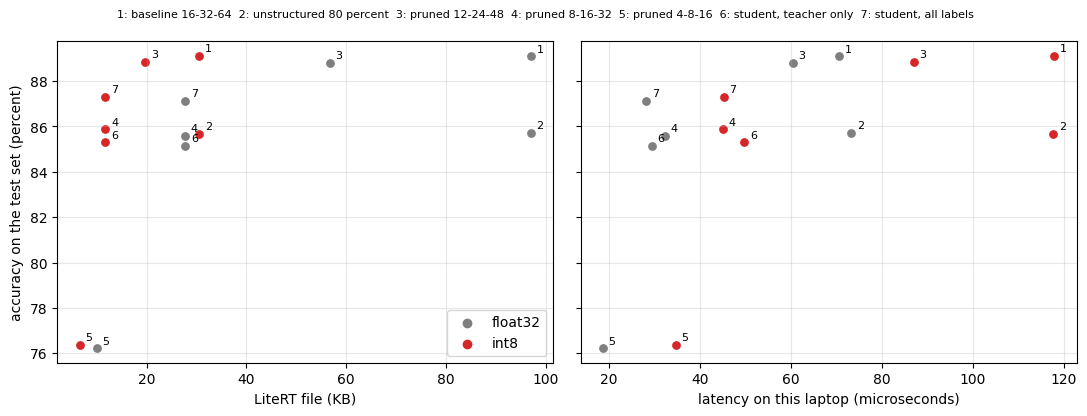

wrote ../tradeoff.png with 7 models


In [16]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
colours = {"float32": "tab:gray", "int8": "tab:red"}
names = list(candidates)
for r in results:
    number = names.index(r["model"]) + 1
    for axis, key in zip(axes, ("bytes", "latency")):
        value = r[key] / 1024 if key == "bytes" else r[key]
        axis.scatter(value, r["accuracy"], color=colours[r["format"]], s=28)
        axis.annotate(str(number), (value, r["accuracy"]), fontsize=8,
                      xytext=(4, 3), textcoords="offset points")
axes[0].set_xlabel("LiteRT file (KB)")
axes[1].set_xlabel("latency on this laptop (microseconds)")
axes[0].set_ylabel("accuracy on the test set (percent)")
for axis in axes:
    axis.grid(alpha=0.3)
for kind, colour in colours.items():
    axes[0].scatter([], [], color=colour, label=kind)
axes[0].legend(loc="lower right")
figure.suptitle("  ".join(f"{k + 1}: {name}" for k, name in enumerate(names)),
                fontsize=8)
figure.tight_layout()
figure.savefig(os.path.join(LAB, "tradeoff.png"), dpi=130)
plt.show()
print(f"wrote {os.path.normpath(os.path.join(LAB, 'tradeoff.png'))} "
      f"with {len(candidates)} models")

## 10. Select one model for each board (20 min)

The two products of this lab have these budgets. They are example budgets:
the model shares each board with other functions.

| Product | Budget | Rule for the selection |
|---|---|---|
| XIAO ESP32S3 | The model file has 16 KB (16 384 bytes) or less. The peak of the activations has 8 KB (8192 bytes) or less. The format is `int8`. | The model with the highest accuracy that meets the budget |
| Raspberry Pi 5 | The accuracy is 88.5 percent or more. The format is `float32` or `int8`. | The model with the smallest latency that meets the budget |

The latency of this notebook is the latency of your laptop. For the lab, use
it as the estimate for the Raspberry Pi. Day 9 measures on the boards.

**Task 7.** Write your selection. Use the model names and the format names
of the table of section 8. Name the constraint that decides: the budget that
removes the next better model.

In [17]:
selection = {
    "XIAO ESP32S3": {
        "model": "student, all labels",
        "format": "int8",
        # "flash", "RAM", or "accuracy"
        "the constraint that decides": "RAM",
    },
    "Raspberry Pi 5": {
        "model": "pruned 12-24-48",
        # "float32" or "int8"
        "format": "float32",
        # "accuracy" or "latency"
        "the constraint that decides": "accuracy",
    },
}

In [18]:
def meets(result, product):
    '''Return True if a LiteRT file meets the budget of a product.'''
    if product == "XIAO ESP32S3":
        return (result["format"] == "int8" and result["bytes"] <= 16384
                and result["peak"] <= 8192)
    return result["accuracy"] >= 88.5


def check_task_7():
    '''Check that each selected file exists and meets its budget.'''
    complete = True
    for product, choice in selection.items():
        found = [r for r in results if r["model"] == choice["model"]
                 and r["format"] == choice["format"]]
        possible = [r for r in results if meets(r, product)]
        if not found:
            print(f"{product}: the table has no file "
                  f"'{choice['model']}' in the format '{choice['format']}'")
            complete = False
            continue
        r = found[0]
        fits = meets(r, product)
        if product == "XIAO ESP32S3":
            better = [p for p in possible if p["accuracy"] > r["accuracy"] + 0.05]
        else:
            better = [p for p in possible if p["latency"] < 0.85 * r["latency"]]
        print(f"{product}: {r['model']} ({r['format']}), {r['bytes']} bytes, "
              f"accuracy {r['accuracy']:.1f}, latency {r['latency']:.0f}, "
              f"peak {r['peak']}")
        print(f"  meets the budget: {'yes' if fits else 'no'}. "
              f"A better file that meets the budget exists: "
              f"{'yes' if better else 'no'}. "
              f"Constraint that decides: {choice['the constraint that decides']}")
        complete = complete and fits and not better \
            and choice["the constraint that decides"] != "?"
    print("Task 7:", "complete" if complete else "not complete")
    return complete


task_7_complete = check_task_7()

XIAO ESP32S3: student, all labels (int8), 12040 bytes, accuracy 87.3, latency 45, peak 7840
  meets the budget: yes. A better file that meets the budget exists: no. Constraint that decides: RAM
Raspberry Pi 5: pruned 12-24-48 (float32), 58104 bytes, accuracy 88.8, latency 60, peak 47040
  meets the budget: yes. A better file that meets the budget exists: no. Constraint that decides: accuracy
Task 7: complete


> Example of a Decision Log.
>
> XIAO ESP32S3: we select the student with all labels in `int8`. It has
> 12 040 bytes and a peak of 7840 bytes, so it meets the two budgets. The RAM
> decides: the models with more filters have a peak of 11 760 bytes or more.
> Three models have this architecture. The student with all labels has the
> highest accuracy of the three.
>
> Raspberry Pi 5: we select the model that is pruned to 12, 24, and 48
> filters, in `float32`. Only two models reach 88.5 percent: the baseline and
> this model. The accuracy decides. The pruned model is a little faster than
> the baseline, and its file is 41 percent smaller. On the laptop, the `int8` files are slower than the `float32`
> files, so we keep `float32`. This can be different on the Raspberry Pi: we
> must measure it there.
>
> The trade-off: the model for the XIAO loses about 2 points against the
> baseline, and it needs half of the RAM.

## Summary

- Unstructured pruning removes most weights with a small loss of accuracy.
  With dense kernels, the device gains nothing from the zeros.
- Structured pruning gives a smaller dense model: less flash, less RAM, and
  less time.
- Distillation gives the largest gain when the teacher makes targets for
  data with no label.
- The selection needs a plot with all candidates and the budgets of the
  product. The constraint that decides is different for each product.